In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
df_test = pd.read_csv('test (1).csv')
df= pd.read_csv('train (1).csv')

In [3]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [315]:
df['ExterQual'].value_counts() 


ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

In [130]:
none_cols = [
    'Alley',           # No alley
    'PoolQC',          # No pool
    'Fence',           # No fence
    'FireplaceQu',     # No fireplace
    'GarageType',      # No garage
    'GarageFinish',    # No garage
    'GarageQual',      # No garage
    'GarageCond',      # No garage
    'BsmtQual',        # No basement
    'BsmtCond',        # No basement
    'BsmtExposure',    # No basement
    'BsmtFinType1',    # No basement
    'BsmtFinType2',    # No basement
    'MasVnrType',       # No masonry
    'MiscFeature'
]
for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('NA')
        print(f" {col}: filled with 'NA'")

 Alley: filled with 'NA'
 PoolQC: filled with 'NA'
 Fence: filled with 'NA'
 FireplaceQu: filled with 'NA'
 GarageType: filled with 'NA'
 GarageFinish: filled with 'NA'
 GarageQual: filled with 'NA'
 GarageCond: filled with 'NA'
 BsmtQual: filled with 'NA'
 BsmtCond: filled with 'NA'
 BsmtExposure: filled with 'NA'
 BsmtFinType1: filled with 'NA'
 BsmtFinType2: filled with 'NA'
 MasVnrType: filled with 'NA'
 MiscFeature: filled with 'NA'


In [129]:
for x in df.columns:
    missing=df[x].isnull().sum()
    if missing!=0 :
        print(f"{x} : {missing}")

LotFrontage : 259
Alley : 1369
MasVnrType : 872
BsmtQual : 37
BsmtCond : 37
BsmtExposure : 38
BsmtFinType1 : 37
BsmtFinType2 : 38
Electrical : 1
FireplaceQu : 690
GarageType : 81
GarageFinish : 81
GarageQual : 81
GarageCond : 81
PoolQC : 1453
Fence : 1179
MiscFeature : 1406


In [131]:
mode_value= df['Electrical'].mode()[0]
print(mode_value)
df['Electrical'] = df['Electrical'].fillna(mode_value)

SBrkr


<Axes: xlabel='LotFrontage', ylabel='Count'>

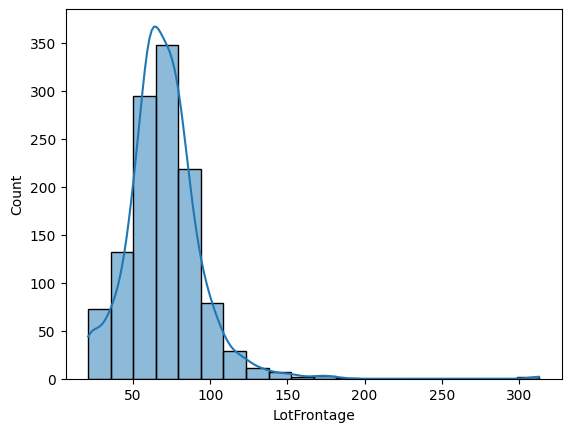

In [7]:
sns.histplot(data=df,x="LotFrontage", bins=20,kde=True) #mean>median>mode(Right skew)

In [132]:
median = df['LotFrontage'].median()
print(median)
df['LotFrontage'] =  df['LotFrontage'].fillna(median)

69.0


<Axes: xlabel='MasVnrArea', ylabel='Count'>

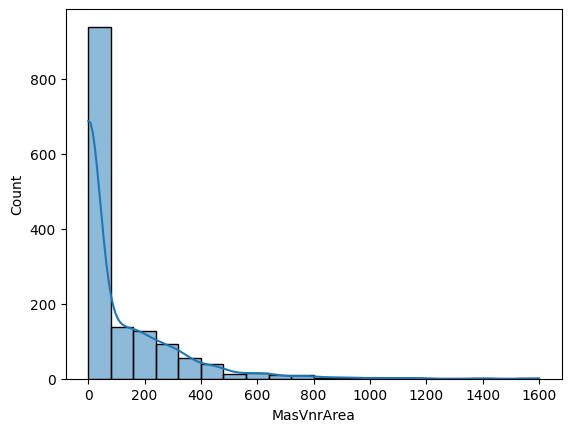

In [9]:
sns.histplot(x=df['MasVnrArea'],bins=20,kde=True)

In [11]:
x= df[df['MasVnrArea'].isnull()==True]
x[['MasVnrArea','MasVnrType']]

,MasVnrArea,MasVnrType
234,NaN,NA
529,NaN,NA
650,NaN,NA
936,NaN,NA
973,NaN,NA
977,NaN,NA
1243,NaN,NA
1278,NaN,NA


In [12]:
df.loc[:234][['MasVnrArea','MasVnrType']]

,MasVnrArea,MasVnrType
0,196.0,BrkFace
1,0.0,NA
2,162.0,BrkFace
3,0.0,NA
4,350.0,BrkFace
...,...,...
230,220.0,BrkFace
231,506.0,BrkFace
232,297.0,BrkFace
233,0.0,NA


In [133]:
df['MasVnrArea']= df['MasVnrArea'].fillna(0)
df['GarageYrBlt']=df['GarageYrBlt'].fillna(0)

In [134]:
duplicates = df.duplicated().sum()
print(duplicates)
df.isnull().sum().sum()

0


np.int64(0)

(bsmtqual, bsmtcond bsmtexposure BsmtFinType1  BsmtFinType2 FireplaceQu GarageFinish,GarageQual,GarageCond,PoolQC)label encoder

garageyrbuilt replace with mean/median

integers = [lotfrontage,MasVnrArea 


In [15]:
for x in df.columns:
    if df[x].dtypes=="str":
        print(x)

MSZoning
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
PoolQC
Fence
MiscFeature
SaleType
SaleCondition


In [149]:


# Define your columns
oneHot = [
    'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType',
    'SaleType', 'SaleCondition', 'MiscFeature'
]

label = [
    'LotShape', 'Utilities', 'LandSlope', 'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond',
    'GarageFinish', 'PavedDrive', 'Functional', 'Fence', 'PoolQC'
]

# Define ordinal categories (from WORST to BEST)
categories = [
    ['IR3', 'IR2', 'IR1', 'Reg'],              # LotShape
    ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],     # Utilities
    ['Sev', 'Mod', 'Gtl'],                     # LandSlope
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],            # ExterQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],            # ExterCond
    ['Po', 'Fa', 'TA', 'Gd', 'Ex', 'NA'],      # BsmtQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex', 'NA'],      # BsmtCond
    ['No', 'Mn', 'Av', 'Gd', 'NA'],            # BsmtExposure
    ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ', 'NA'], # BsmtFinType1
    ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ', 'NA'], # BsmtFinType2
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],            # HeatingQC
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],            # KitchenQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex', 'NA'],      # FireplaceQu
    ['Po', 'Fa', 'TA', 'Gd', 'Ex', 'NA'],      # GarageQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex', 'NA'],      # GarageCond
    ['Unf', 'RFn', 'Fin', 'NA'],               # GarageFinish
    ['N', 'P', 'Y'],                           # PavedDrive
    ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'], # Functional
    ['MnWw', 'GdWo', 'MnPrv', 'GdPrv', 'NA'],  # Fence
    ['Fa', 'TA', 'Gd', 'Ex', 'NA']             # PoolQC
]

df_encoded = pd.get_dummies(df, columns=oneHot, drop_first=True, dtype=int)

encoder = OrdinalEncoder(categories=categories)
df_encoded[label] = encoder.fit_transform(df_encoded[label])

df_test_encoded = pd.get_dummies(df_test, columns=oneHot, drop_first=True, dtype=int)

df_test_encoded[label] = encoder.transform(df_test_encoded[label])

print("✓ Training data encoded shape:", df_encoded.shape)
print("✓ Test data encoded shape:", df_test_encoded.shape)

✓ Training data encoded shape: (1460, 204)
✓ Test data encoded shape: (1459, 188)


In [18]:
for x in df_encoded.columns:
    missing =df_encoded[x].isnull().sum()
    if missing !=0:
        print(x)

In [168]:
df_encoded.shape

(1460, 204)

In [22]:
correlations = df_encoded.corr()['SalePrice'].sort_values(ascending=False)
print(correlations.head())

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
ExterQual      0.682639
KitchenQual    0.659600
Name: SalePrice, dtype: float64


In [174]:
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded["SalePrice"]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
model =LinearRegression()
model.fit(x_scaled,y)
X.shape


(1460, 203)

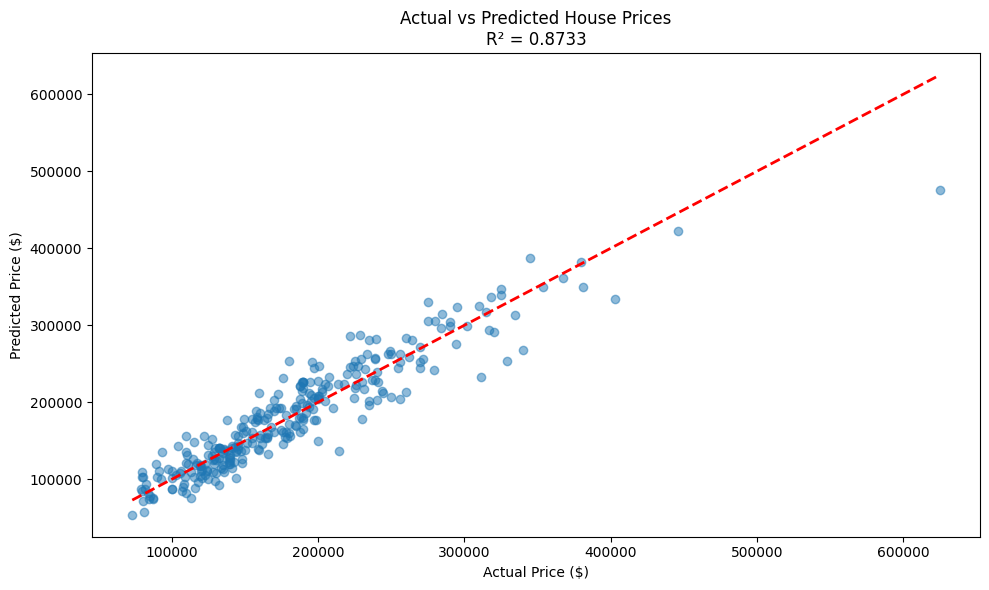

In [67]:

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted House Prices\nR² = {r2:.4f}')
plt.tight_layout()
plt.show()

In [68]:
df_test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [110]:
for x in df_test.columns:
    missing = df_test[x].isnull().sum()
    if missing !=0:
        print(x,missing, df_test[x].dtypes)
        if df_test[x].dtypes == "str":
            mode = df_test[x].mode()[0]
            df_test[x] = df_test[x].fillna(mode)
            print(f"filled for {x}")


In [70]:
none_cols = [
    'Alley',           # No alley
    'PoolQC',          # No pool
    'Fence',           # No fence
    'FireplaceQu',     # No fireplace
    'GarageType',      # No garage
    'GarageFinish',    # No garage
    'GarageQual',      # No garage
    'GarageCond',      # No garage
    'BsmtQual',        # No basement
    'BsmtCond',        # No basement
    'BsmtExposure',    # No basement
    'BsmtFinType1',    # No basement
    'BsmtFinType2',    # No basement
    'MasVnrType',       # No masonry
    'MiscFeature'
]
for col in none_cols:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('NA')
        print(f" {col}: filled with 'NA'")

 Alley: filled with 'NA'
 PoolQC: filled with 'NA'
 Fence: filled with 'NA'
 FireplaceQu: filled with 'NA'
 GarageType: filled with 'NA'
 GarageFinish: filled with 'NA'
 GarageQual: filled with 'NA'
 GarageCond: filled with 'NA'
 BsmtQual: filled with 'NA'
 BsmtCond: filled with 'NA'
 BsmtExposure: filled with 'NA'
 BsmtFinType1: filled with 'NA'
 BsmtFinType2: filled with 'NA'
 MasVnrType: filled with 'NA'
 MiscFeature: filled with 'NA'


In [72]:
mode_value= df_test['Electrical'].mode()[0]
print(mode_value)
df_test['Electrical'] = df_test['Electrical'].fillna(mode_value)

SBrkr


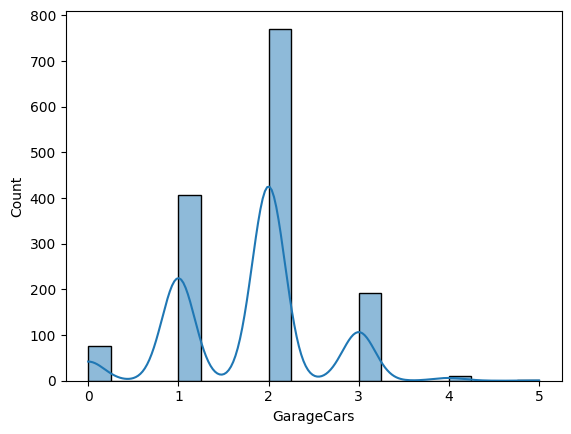

In [99]:
df_test['MasVnrArea']= df_test['MasVnrArea'].fillna(0)
df_test['GarageYrBlt']=df_test['GarageYrBlt'].fillna(0)
mz_zone = df_test['MSZoning'].mode()[0]
df_test['MSZoning'] = df_test['MSZoning'].fillna(mz_zone)
sns.histplot(data=df_test, x='GarageCars', bins=20, kde=True)
lot_median = df_test['LotFrontage'].median()
df_test['LotFrontage'] = df_test['LotFrontage'].fillna(lot_median)
uti_mode = df_test['Utilities'].mode()[0]
df_test['Utilities'] = df_test['Utilities'].fillna(uti_mode)
df_test['SaleType'] = df_test['SaleType'].fillna(df_test['SaleType'].mode()[0])
gar_median = df_test['GarageArea'].median()
df_test['GarageArea'] = df_test['GarageArea'].fillna(gar_median)
df_test['GarageCars'] = df_test['GarageCars'].fillna(df_test['GarageCars'].median())


In [111]:
i=1
plt.figure(figsize=(12,8))
for p in df_test.columns:
    missing = df_test[p].isnull().sum()
    if missing !=0:
        plt.subplot(2,3,i)
        sns.histplot(data = df_test, x=p, kde=True, bins=20)
        medianP = df_test[p].median()
        df_test[p] = df_test[p].fillna(medianP)
        i=i+1
plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

In [112]:
df_test.isnull().sum().sum()

np.int64(0)

In [139]:
df_test_encoded.dtypes

Id                         int64
MSSubClass                 int64
LotFrontage              float64
LotArea                    int64
LotShape                 float64
                          ...   
SaleCondition_Normal       int64
SaleCondition_Partial      int64
MiscFeature_NA             int64
MiscFeature_Othr           int64
MiscFeature_Shed           int64
Length: 188, dtype: object

In [151]:
df_test_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,MiscFeature_NA,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC
0,1461,20,80.0,11622,3.0,3.0,2.0,5,6,1961,...,1,0,0,0,1,0,1,0,0,0
1,1462,20,81.0,14267,2.0,3.0,2.0,6,6,1958,...,1,0,0,0,1,0,0,0,0,0
2,1463,60,74.0,13830,2.0,3.0,2.0,5,5,1997,...,1,0,0,0,1,0,1,0,0,0
3,1464,60,78.0,9978,2.0,3.0,2.0,6,6,1998,...,1,0,0,0,1,0,1,0,0,0
4,1465,120,43.0,5005,2.0,3.0,2.0,8,5,1992,...,1,0,0,0,1,0,1,0,0,0


In [144]:
df_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,MiscFeature_NA,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC
0,1,60,65.0,8450,3.0,1.0,2.0,7,5,2003,...,1,0,0,0,1,0,1,0,0,0
1,2,20,80.0,9600,3.0,1.0,2.0,6,8,1976,...,1,0,0,0,1,0,1,0,0,0
2,3,60,68.0,11250,2.0,1.0,2.0,7,5,2001,...,1,0,0,0,1,0,1,0,0,0
3,4,70,60.0,9550,2.0,1.0,2.0,7,5,1915,...,1,0,0,0,0,0,1,0,0,0
4,5,60,84.0,14260,2.0,1.0,2.0,8,5,2000,...,1,0,0,0,1,0,1,0,0,0


In [182]:
df.shape
df_test_encoded.shape
df_encoded.shape
X.shape
p=df_test_encoded[X.columns].values
predict = model.predict(p)
predict

array([1.08948194e+08, 1.47681855e+08, 1.42571440e+08, ...,
       1.63577885e+08, 9.51540823e+07, 1.35739807e+08], shape=(1459,))